# M6：公開風速 Data1 的點預測與區間預測

本筆記本使用 Ding et al. 論文作者公開 repository 的 `Data1.csv`，只取 `Wind speed` 欄位。原論文每組原始資料有 1,440 筆（1,240 training、100 validation、100 testing）；公開 CSV 因建立四階落後特徵只剩 1,436 筆，因此固定最後 100 筆為相同 testing segment，其餘 1,336 筆作為 M6 的 test 前可用資料。M6 的 rolling-origin cross-fit 與 residual-window 選擇只在這 1,336 筆內完成。

第一次執行需要網路下載公開 CSV；之後會優先讀取 `data/raw/wind_speed_data1.csv`。

In [1]:
from pathlib import Path
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src' / 'kf_forecasting').exists()), None)
if ROOT is None:
    raise RuntimeError('請由 project/meeting 或其子資料夾開啟本 notebook')
sys.path.insert(0, str(ROOT / 'src'))

from kf_forecasting.models.kf_enbpi import EnbPIConfig
from kf_forecasting.models.kf_out_of_time_enbpi import (
    OutOfTimeEnbPIConfig, locally_scaled_from_fitted,
    plot_window_selection, run_out_of_time_enbpi
)

SEED = 2026
ALPHA = 0.05
TEST_SIZE = 100
DATA_URL = 'https://raw.githubusercontent.com/hyuzhou/Wind-speed-forecasting-/master/Data/Data1.csv'
DATA_PATH = ROOT / 'data' / 'raw' / 'wind_speed_data1.csv'
print('Project root:', ROOT)

Project root: c:\Users\User\Desktop\程式\project\meeting


## 1. 載入並核對 Data1

總筆數=1436, M6 test 前資料=1336, test=100


,count,mean,std,min,25%,50%,75%,max
Wind speed,1436.0,6.630425,3.76737,0.29,3.58,6.23,9.205,16.29


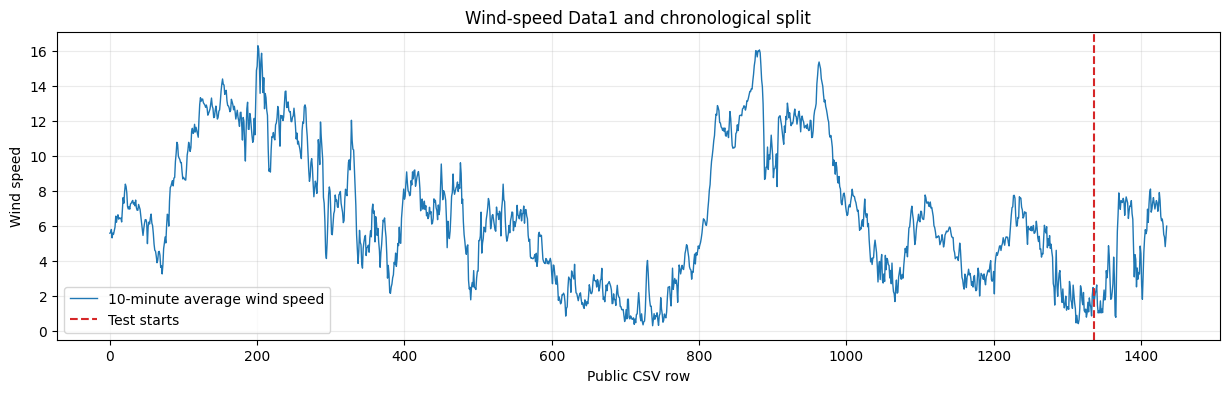

In [2]:
if DATA_PATH.exists():
    data = pd.read_csv(DATA_PATH)
else:
    data = pd.read_csv(DATA_URL)
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    data.to_csv(DATA_PATH, index=False)

data.columns = data.columns.str.strip()
if 'Wind speed' not in data.columns:
    raise KeyError(f'找不到 Wind speed 欄位；現有欄位：{data.columns.tolist()}')
y = pd.to_numeric(data['Wind speed'], errors='coerce').to_numpy(float)
if not np.isfinite(y).all():
    raise ValueError('Wind speed 含缺失值或非數值')
if len(y) != 1436:
    print(f'警告：目前公開資料有 {len(y)} 筆，不是預期的 1436 筆，請重新核對版本。')
TRAIN_SIZE = len(y) - TEST_SIZE
print(f'總筆數={len(y)}, M6 test 前資料={TRAIN_SIZE}, test={TEST_SIZE}')
display(data[['Wind speed']].describe().T)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(y, lw=1, label='10-minute average wind speed')
ax.axvline(TRAIN_SIZE, color='tab:red', ls='--', label='Test starts')
ax.set(xlabel='Public CSV row', ylabel='Wind speed', title='Wind-speed Data1 and chronological split')
ax.grid(alpha=.25); ax.legend(); plt.show()

## 2. 設定並執行 M6

下列設定沿用目前 M6 原始尺度版本：95% interval、30 個 bootstrap hybrid models、ARIMA 由 BIC 選擇、ANN rolling-origin iteration selection，以及 training-only adaptive residual window。執行時間可能較長。

In [3]:
base_cfg = EnbPIConfig(
    window_size=15, alpha=ALPHA, n_bootstrap=30, batch_size=1,
    beta_grid_size=101, oob_bias_correction=True,
    oob_bias_correction_mode='combined', arima_order=None,
    arima_max_p=4, arima_max_q=4, arima_max_iter=500,
    ann_hidden_layers=(32, 16), ann_max_iter=500,
    ann_alpha=1e-4, ann_learning_rate_init=1e-3,
    ann_target_standardization=True, ann_early_stopping=False,
    ann_rolling_validation=True, ann_rolling_splits=3,
    ann_validation_fraction=.10, ann_tol=1e-3, random_state=SEED,
    process_variance=.5, measurement_variance=10.0,
)
cfg = OutOfTimeEnbPIConfig(
    base=base_cfg, initial_train_fraction=.5, n_crossfit_blocks=4,
    residual_window_candidates=(100, 200, 300, 400, None),
    window_validation_fraction=.4, min_window_history=40,
)

started = time.perf_counter()
result = run_out_of_time_enbpi(y, TRAIN_SIZE, config=cfg, model_name='Wind Data1')
local_result = locally_scaled_from_fitted(
    result, pd.Index(np.arange(1, TEST_SIZE + 1), name='test_step'),
    neighbours=60, support_lower=None
)
runtime_seconds = time.perf_counter() - started
print(f'M6 finished in {runtime_seconds:.1f} seconds')

M6 finished in 425.1 seconds


## 3. 點預測與區間預測摘要

In [4]:
raw_pred = result.forecast.frame().copy()
raw_pred.insert(0, 'test_step', np.arange(1, len(raw_pred) + 1))
local_pred = local_result.predictions.rename(columns={'date': 'test_step'}).copy()

def metric_row(method, frame, selected_window, runtime):
    error = frame['truth'] - frame['point']; width = frame['upper'] - frame['lower']
    lower_miss = frame['truth'] < frame['lower']; upper_miss = frame['truth'] > frame['upper']
    score = width + 2/ALPHA*(frame['lower']-frame['truth']).clip(lower=0) + 2/ALPHA*(frame['truth']-frame['upper']).clip(lower=0)
    return {'method': method, 'n_test': len(frame), 'MSE': np.mean(error**2),
            'RMSE': np.sqrt(np.mean(error**2)), 'MAE': np.mean(np.abs(error)),
            'Coverage (%)': 100*np.mean(~(lower_miss|upper_miss)),
            'Mean width': np.mean(width), 'Median width': np.median(width),
            'PINAW': np.mean(width)/(raw_pred['truth'].max()-raw_pred['truth'].min()),
            'Lower miss (%)': 100*np.mean(lower_miss), 'Upper miss (%)': 100*np.mean(upper_miss),
            'Interval score': np.mean(score), 'Selected residual window': selected_window,
            'Runtime (sec)': runtime}

summary = pd.DataFrame([
    metric_row('M6 OOT Adaptive EnbPI', raw_pred, 'all' if result.selected_residual_window is None else result.selected_residual_window, runtime_seconds),
    metric_row('M6 OOT Adaptive EnbPI + Local-scale', local_pred, 'all' if local_result.selected_window is None else local_result.selected_window, runtime_seconds),
])
predictions = pd.concat([
    raw_pred[['test_step','truth','point','lower','upper']].assign(method='M6 OOT Adaptive EnbPI'),
    local_pred[['test_step','truth','point','lower','upper','local_scale']].assign(method='M6 OOT Adaptive EnbPI + Local-scale'),
], ignore_index=True)
display(summary.round(4))
display(result.window_selection.round(4))
display(local_result.window_selection.round(4))
display(predictions.round(4))

,method,n_test,MSE,RMSE,MAE,Coverage (%),Mean width,Median width,PINAW,Lower miss (%),Upper miss (%),Interval score,Selected residual window,Runtime (sec)
0,M6 OOT Adaptive EnbPI,100,0.8325,0.9124,0.6804,82.0,2.4801,2.4670,0.3383,9.0,9.0,6.8231,400,425.1442
1,M6 OOT Adaptive EnbPI + Local-scale,100,0.8308,0.9115,0.6801,87.0,3.1309,3.0992,0.4271,5.0,8.0,5.5168,300,425.1442


,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,400,400.0,2.6492,0.9478,2.2094,268,400,True
1,all,NaN,2.6978,0.9552,2.1465,268,400,False
2,300,300.0,2.7955,0.9440,2.1782,268,400,False
3,200,200.0,2.8425,0.9254,2.0464,268,400,False
4,100,100.0,2.8918,0.9179,1.8817,268,400,False


,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,300,300.0,8.4561,0.9440,6.6977,268,400,True
1,all,NaN,8.4955,0.9515,6.6770,268,400,False
2,120,120.0,8.5442,0.9291,5.9664,268,400,False
3,180,180.0,8.6394,0.9328,6.0872,268,400,False
4,60,60.0,8.6692,0.9179,5.7943,268,400,False
5,24,24.0,10.1046,0.8619,5.0350,268,400,False


,test_step,truth,point,lower,upper,method,local_scale
0,1,1.81,2.1173,1.1756,3.3428,M6 OOT Adaptive EnbPI,NaN
1,2,1.80,1.7879,0.8478,3.0150,M6 OOT Adaptive EnbPI,NaN
2,3,2.15,1.7122,0.7716,2.9388,M6 OOT Adaptive EnbPI,NaN
3,4,2.30,2.0843,1.1412,3.3084,M6 OOT Adaptive EnbPI,NaN
4,5,2.62,2.2427,1.3008,3.4680,M6 OOT Adaptive EnbPI,NaN
...,...,...,...,...,...,...,...
195,96,5.50,6.0475,4.5696,7.6446,M6 OOT Adaptive EnbPI + Local-scale,0.4030
196,97,5.36,5.4682,3.8959,7.1681,M6 OOT Adaptive EnbPI + Local-scale,0.4288
197,98,4.81,5.3822,3.9412,6.9338,M6 OOT Adaptive EnbPI + Local-scale,0.3922
198,99,5.35,5.1232,3.6316,6.7321,M6 OOT Adaptive EnbPI + Local-scale,0.4063


## 4. 最終預測圖與 residual-window 選擇圖

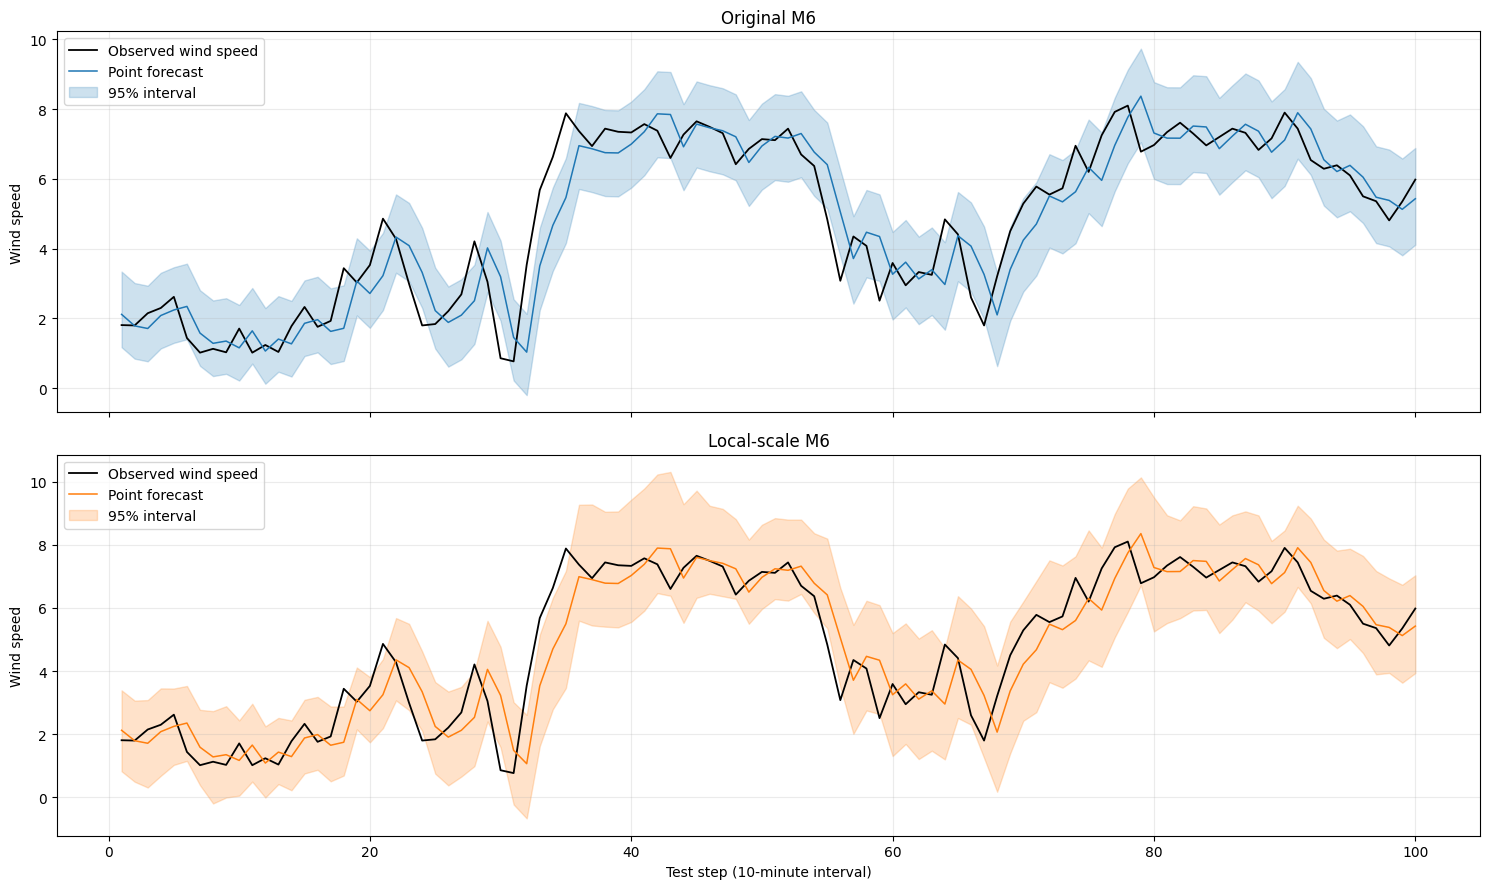

C:\Users\User\AppData\Local\Temp\ipykernel_45496\1392254296.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_window_selection(result)[0].show()


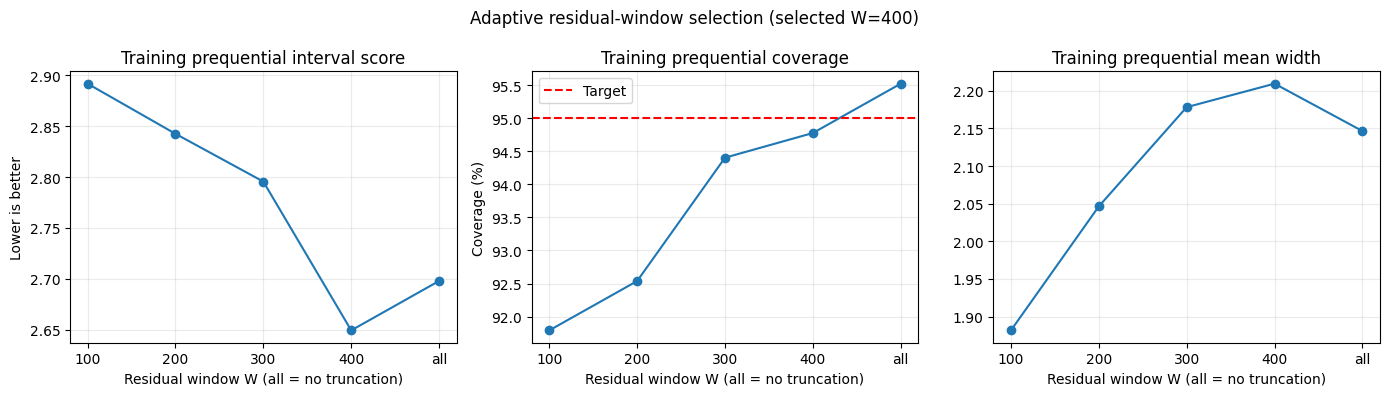

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for ax, (title, frame, color) in zip(axes, [
    ('Original M6', raw_pred, 'tab:blue'),
    ('Local-scale M6', local_pred, 'tab:orange')
]):
    x = frame['test_step'].to_numpy()
    ax.plot(x, frame['truth'], color='black', lw=1.3, label='Observed wind speed')
    ax.plot(x, frame['point'], color=color, lw=1.1, label='Point forecast')
    ax.fill_between(x, frame['lower'], frame['upper'], color=color, alpha=.22, label='95% interval')
    ax.set(ylabel='Wind speed', title=title); ax.grid(alpha=.25); ax.legend()
axes[-1].set_xlabel('Test step (10-minute interval)')
fig.tight_layout(); plt.show()

plot_window_selection(result)[0].show()

## 5. 選擇性輸出

取消下方註解即可保存 summary、逐期預測與圖片。這些輸出只代表公開 Data1；不可宣稱重現論文的 Data2。

In [ ]:
# OUTPUT_DIR = ROOT / 'results' / 'wind_speed_data1_m6'
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False)
# pred.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
# fig.savefig(OUTPUT_DIR / 'point_and_interval_forecast.png', dpi=180, bbox_inches='tight')